Mini-project: Advanced Statistical Analysis of Apple Inc. Stock Data


👩‍🏫 👩🏿‍🏫 What You’ll learn
Master statistical analysis of financial data using NumPy and SciPy.
Learn effective data visualization techniques with Matplotlib for financial trends.
Apply hypothesis testing to financial datasets for meaningful insights.
Understand and utilize advanced statistical techniques in NumPy and SciPy.


Project Description
Using the AAPL (Apple Inc.) stock dataset, conduct the following analyses:



Initial Data Exploration
Load the dataset using Pandas. Check for null values and understand data types.
Examine the time series properties of the data (e.g., frequency, trends).


Data Visualization
Utilize Matplotlib to plot closing prices and traded volume over time.
Create a candlestick chart to depict high and low prices.


Statistical Analysis
Compute summary statistics (mean, median, standard deviation) for key columns.
Analyze closing prices with a moving average.


Hypothesis Testing
Execute a t-test to compare average closing prices across different years.
Examine daily returns’ distribution and test for normality using SciPy.


Advanced Statistical Techniques (Bonus)
Statistical Functions in NumPy: Employ NumPy’s statistical functions for in-depth stock data analysis.
E.g., Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.
Analyze correlations between moving averages of closing prices and trading volume across time periods.


Resources
Dataset: download it here Apple Stock Prices From 1981 to 2023
It may include data such as date, opening price, closing price, high and low prices, and trading volume.

This information can be used to study trends and patterns in the stock market and make informed investment decisions.

Date: Represents the date of the stock price.
Open: Represents the opening stock price on that date.
High: Represents the highest stock price on that date.
Low: Represents the lowest stock price on that date.
Close: Represents the closing stock price on that date.
Adj close: Represents the adjusted closing stock price on that date (taking into account corporate actions such as splits).
Volume: Represents the number of shares traded on that date.

In [94]:
# 1. Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats
data_orig = pd.read_csv('Apple Stock Prices (1981 to 2023).csv')
df = pd.DataFrame(data_orig)
df.head(20)

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200
5,09/01/1981,0.142299,0.142857,0.142299,0.142299,0.110730,21504000
6,12/01/1981,0.142299,0.142299,0.141183,0.141183,0.109861,23699200
7,13/01/1981,0.136719,0.136719,0.136161,0.136161,0.105953,23049600
8,14/01/1981,0.136719,0.137277,0.136719,0.136719,0.106388,14291200
9,15/01/1981,0.139509,0.140625,0.139509,0.139509,0.108559,14067200


In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  str    
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 580.3 KB


In [79]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


In [95]:
# 1. Data Exploration on:  Date Range
# set date as DatetimeIndex
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.set_index('Date')  # Assign it!
df = df.sort_index()  # Sort by index, not by column
print(f'Date range: {df.index.min().date()} - {df.index.max().date()}')

Date range: 1981-01-02 - 2023-01-27


In [96]:
#  1. Data Exploration on: frequency 
# Infer the frequency
freq = pd.infer_freq(df.index)
print(f'Inferred frequency: {freq}')
# it returns None

# check differences between dates
date_diffs = df.index.to_series().diff().value_counts()
print(f'Most common gap between dates: \n{date_diffs.head()}')
print('as we see the most common gap is 1 day or 3 days, which makes sense that the stock market is open daily, but on the weekend it is closed. And sometimes the gap is big, which can mean that stock market holidays or unusual events had happened.')

full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')  # 'B' = business days
missing = full_range.difference(df.index)
print(f"Missing trading days: {len(missing)}")

Inferred frequency: None
Most common gap between dates: 
Date
1 days    8317
3 days    1927
4 days     265
2 days      95
5 days       2
Name: count, dtype: int64
as we see the most common gap is 1 day or 3 days, which makes sense that the stock market is open daily, but on the weekend it is closed. And sometimes the gap is big, which can mean that stock market holidays or unusual events had happened.
Missing trading days: 368


0.154018
145.929993
Overall change: 94648.66%
comparing the stock price from the beginning and lately, we see it has grown drastically.


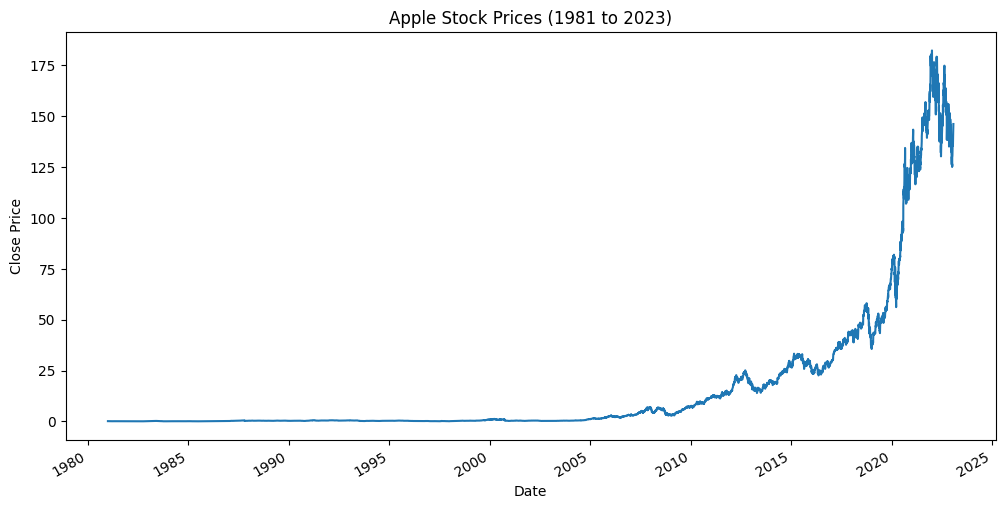

What I Observed: Apple's stock price demonstrates a dramatic upward trend spanning four decades. Growth was gradual from 1981 to 2009, but accelerated significantly beginning in 2010, rising exponentially through 2021. In 2022, the stock experienced a notable correction, declining from its peak. Despite this pullback, the stock remains substantially elevated compared to historical levels.


In [82]:
#  1. Data Exploration on: Examine the trends
print(df['Close'].iloc[0])   # first price
print(df['Close'].iloc[-1])  # last price
print(f"Overall change: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%")
print(f'comparing the stock price from the beginning and lately, we see it has grown drastically.')
# plot closing price to visualize trend
df['Close'].plot(figsize=(12, 6), title='Apple Stock Prices (1981 to 2023)')
plt.ylabel('Close Price')
plt.xlabel('Date')
plt.show()
print("What I Observed: Apple's stock price demonstrates a dramatic upward trend spanning four decades. Growth was gradual from 1981 to 2009, but accelerated significantly beginning in 2010, rising exponentially through 2021. In 2022, the stock experienced a notable correction, declining from its peak. Despite this pullback, the stock remains substantially elevated compared to historical levels.")

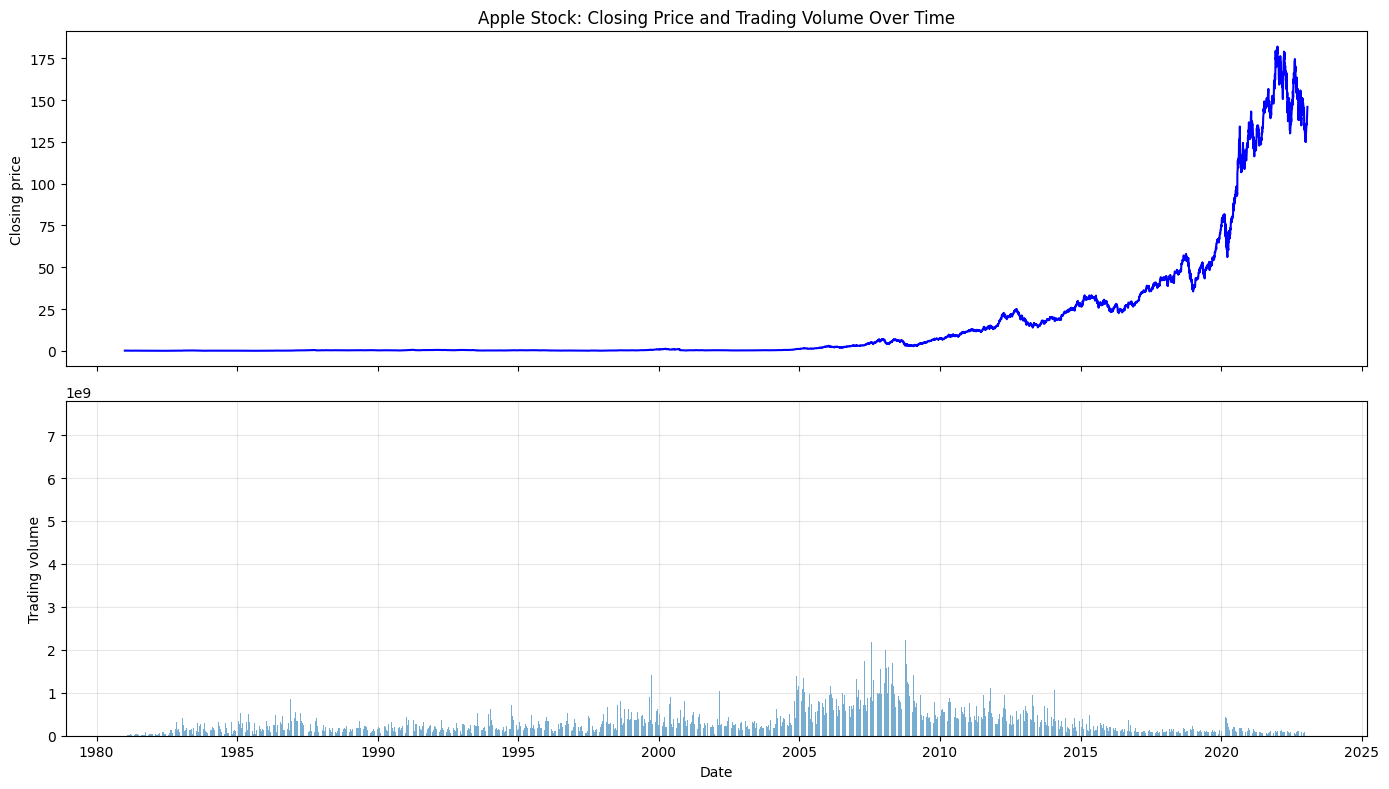

In [83]:
# 2. Data visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(df.index, df['Close'], color='blue')
ax1.set_ylabel('Closing price')
ax1.set_title('Apple Stock: Closing Price and Trading Volume Over Time')

ax2.bar(df.index, df['Volume'], alpha=0.6, width=1)
ax2.set_ylabel('Trading volume')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
# Q1: from the volume charts: which chart is the best to use? Bar, line, histogram(with range)???
# Q2: what can I learn from the volume chart? between 2005 and 2009 , high volume???

50


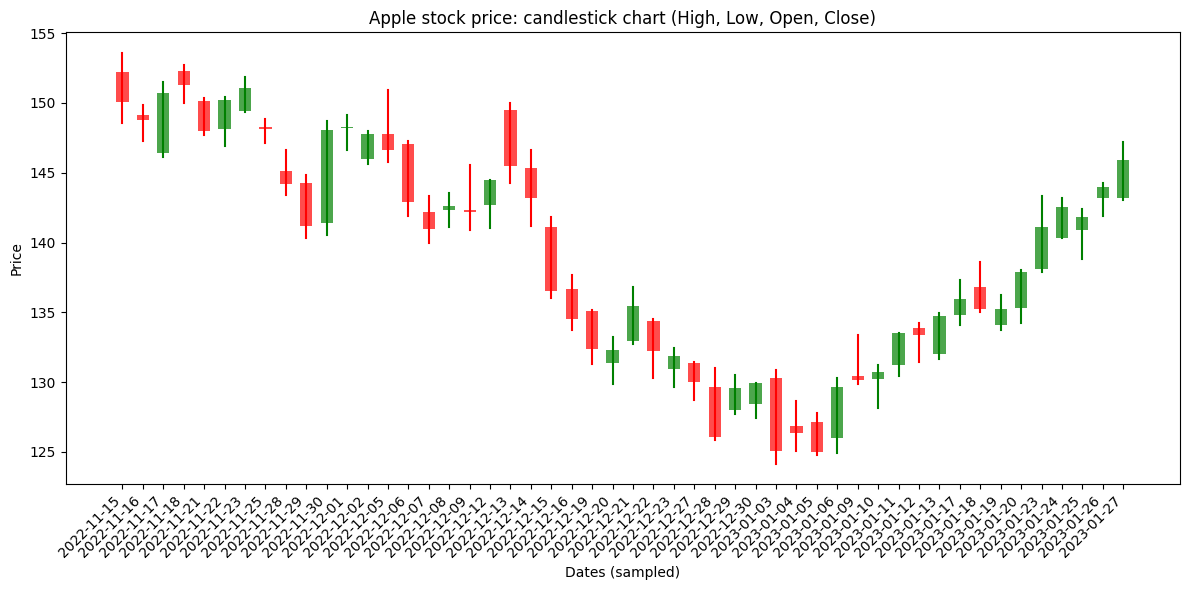

In [84]:
# 2. Data visualization on : candlestick chart

sample_df = df.tail(50)
# sample_df = df.iloc[::50]
print(len(sample_df))
fig, ax = plt.subplots(figsize=(12, 6))

for i, (date, row) in enumerate(sample_df.iterrows()):
    # print(row)
    open_price = row['Open']
    close_price = row['Close']
    high_price = row['High']
    low_price = row['Low']
    
    # color is green is close > open, red if close < open
    color = 'green' if close_price >= open_price else 'red'
    
    # draw the wick (vertical line)
    ax.plot([i, i], [low_price, high_price], color=color)
    # draw the body (rectangle)
    body_height = abs(open_price - close_price)
    body_bottom = min(open_price, close_price)
    rect = patches.Rectangle([i-0.3, body_bottom], 0.6, body_height, linewidth=1, facecolor=color, alpha=0.7)
    ax.add_patch(rect)

ax.set_xticks(range(len(sample_df)))
ax.set_xticklabels([date.strftime('%Y-%m-%d') for date in sample_df.index], rotation=45, ha='right')
ax.set_ylabel('Price')
ax.set_xlabel('Dates (sampled)')
ax.set_title('Apple stock price: candlestick chart (High, Low, Open, Close)')
plt.tight_layout()
plt.show()

In [85]:
# 3. Statistical Analysis: 
#  compute summary statistics for key columns

key_columns = list(df.columns)
print(key_columns)
stats = pd.DataFrame({
    'Mean': df[key_columns].mean(),
    'Median': df[key_columns].median(),
    'Std Dev': df[key_columns].std(),
    'Min': df[key_columns].min(),
    'Max': df[key_columns].max()
})
# print(stats.round(2))
print(stats)


['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
                   Mean        Median       Std Dev       Min           Max
Open       1.668917e+01  4.888390e-01  3.545052e+01  0.049665  1.826300e+02
High       1.687996e+01  4.955360e-01  3.588285e+01  0.049665  1.829400e+02
Low        1.650082e+01  4.804465e-01  3.503129e+01  0.049107  1.791200e+02
Close      1.669736e+01  4.877010e-01  3.547391e+01  0.049107  1.820100e+02
Adj Close  1.602735e+01  4.048505e-01  3.515488e+01  0.038213  1.809597e+02
Volume     3.275098e+08  2.145976e+08  3.378203e+08  0.000000  7.421641e+09


Date
1981-01-02           NaN
1981-05-27           NaN
1981-10-16           NaN
1982-03-11           NaN
1982-08-03      0.102679
                 ...    
2021-06-16    104.875000
2021-11-05    122.033000
2022-03-31    143.983501
2022-08-24    152.528000
2023-01-18    151.756000
Name: Close, Length: 107, dtype: float64


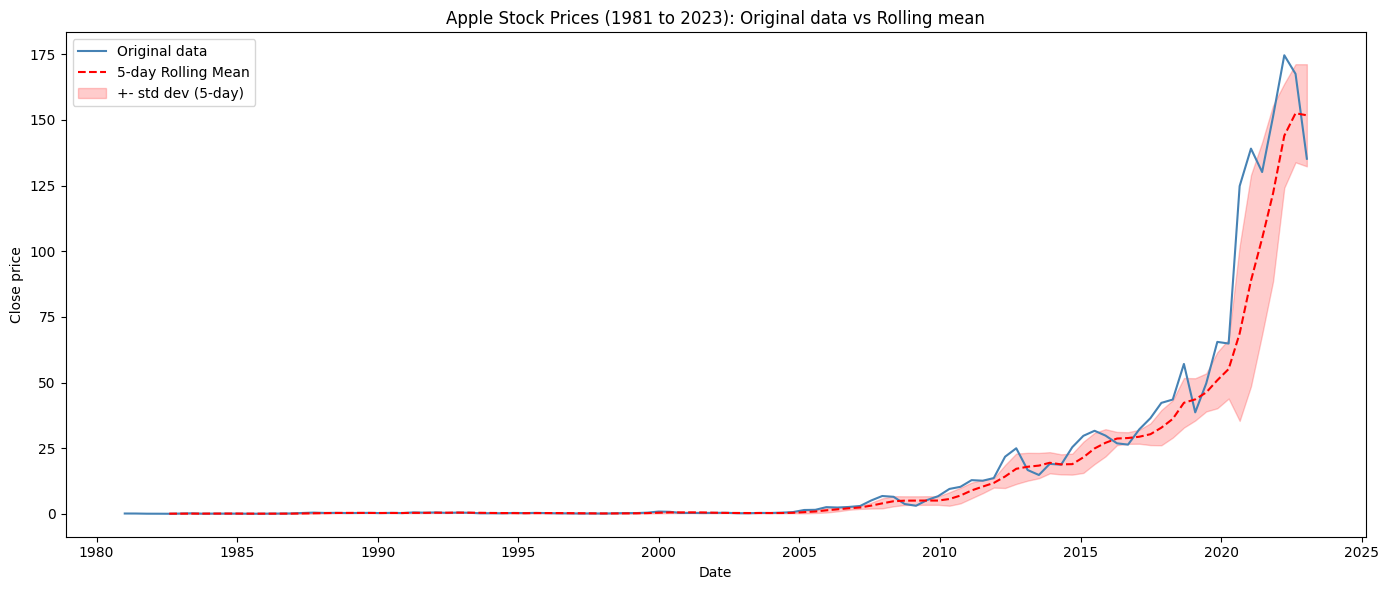

In [86]:
# Analyze closing prices with a moving average.
# orig_data = df 
orig_data = df.iloc[::100] # sampling
window_size = 5 # or increase to 200

moving_average = orig_data['Close'].rolling(window=window_size).mean()
moving_std = orig_data['Close'].rolling(window=window_size).std()
print(moving_average)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(orig_data.index, orig_data['Close'], label='Original data', color='steelblue')
ax.plot(orig_data.index, moving_average, label=f'{window_size}-day Rolling Mean', color='red', linestyle='--')
ax.fill_between(orig_data.index, moving_average - moving_std, moving_average + moving_std, color='red',alpha=0.2, label=f'+- std dev ({window_size}-day)')

ax.set_xlabel('Date')
ax.set_ylabel('Close price')
ax.set_title('Apple Stock Prices (1981 to 2023): Original data vs Rolling mean')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()
# ??? Q: in the chart, the rolling mean is very similar to original data, and confidence band is barely visible, 
# what can we do to improve this? sample data? increase window size?

In [109]:
# 4. Hypothesis test
# Execute a t-test to compare average closing prices across different years. ??? T-test or Anova
# from scipy.stats import ttest_ind

# need to group data by year and calculate average and compare them
close_2000 = df[df.index.year == 2000]['Close']
close_2010 = df[df.index.year == 2010]['Close']
close_2020 = df[df.index.year == 2020]['Close']
print(close_2000.head())
print(close_2010.head())
print(close_2020.head())

print("=" * 70)
print("T-TEST: Comparing Average Closing Prices Across Different Years")
print("=" * 70)
# Compare 2000 vs 2010
t_stat_1, p_value_1 = stats.ttest_ind(close_2000.values, close_2010.values)

print(f"  2000 - Mean: ${close_2000.mean():.2f}")
print(f"  2010 - Mean: ${close_2010.mean():.2f}")
print(f"  T-statistic: {t_stat_1:.4f}, P-value: {p_value_1:.6f}")
print(f"  Result: {'Significant difference ✓' if p_value_1 < 0.05 else 'No significant difference ✗'}")

# Compare 2010 vs 2020
t_stat_2, p_value_2 = stats.ttest_ind(close_2010.values, close_2020.values)

print(f"  2010 - Mean: ${close_2010.mean():.2f}")
print(f"  2020 - Mean: ${close_2020.mean():.2f}")
print(f"  T-statistic: {t_stat_2:.4f}, P-value: {p_value_2:.6f}")
print(f"  Result: {'Significant difference ✓' if p_value_2 < 0.05 else 'No significant difference ✗'}")

# ANONA analysis: to compare three or more groups
close_all_years = [values['Close'].values for year, values in df.groupby(df.index.year)]
f_stat, p_value = stats.f_oneway(*close_all_years) # * is for unpacking a list into separate arguments
print("=" * 70)
print("ANOVA: Comparing Closing Prices Across ALL Years")
print("=" * 70)
print(f"Number of years: {len(close_all_years)}")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("Result: ✓ Significant differences exist across years")
else:
    print("Result: ✗ No significant difference across years")

# Show average price per year
yearly_avg = df['Close'].groupby(df.index.year).mean()
print(f"\nAverage closing price by year:\n{yearly_avg}")

Date
2000-01-03    0.999442
2000-01-04    0.915179
2000-01-05    0.928571
2000-01-06    0.848214
2000-01-07    0.888393
Name: Close, dtype: float64
Date
2010-01-04    7.643214
2010-01-05    7.656429
2010-01-06    7.534643
2010-01-07    7.520714
2010-01-08    7.570714
Name: Close, dtype: float64
Date
2020-01-02    75.087502
2020-01-03    74.357498
2020-01-06    74.949997
2020-01-07    74.597504
2020-01-08    75.797501
Name: Close, dtype: float64
T-TEST: Comparing Average Closing Prices Across Different Years
  2000 - Mean: $0.82
  2010 - Mean: $9.28
  T-statistic: -97.7371, P-value: 0.000000
  Result: Significant difference ✓
  2010 - Mean: $9.28
  2020 - Mean: $95.35
  T-statistic: -62.5269, P-value: 0.000000
  Result: Significant difference ✓
ANOVA: Comparing Closing Prices Across ALL Years
Number of years: 43
F-statistic: 12936.8983
P-value: 0.0000000000
Result: ✓ Significant differences exist across years

Average closing price by year:
Date
1981      0.108548
1982      0.085459
198